In [21]:
import os
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
import pathlib
import dill
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sess = u.load_single_day('SparseKO_02',0)

{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1, 'ravel_ind': 0}


In [3]:
sess.trial_info.keys()

dict_keys(['block_number', 'LR'])

In [4]:
sess.place_cell_info['channel_0_F_dff']

{'left': {'masks': array([ True,  True,  True, False,  True, False, False,  True, False,
          True,  True,  True, False,  True,  True,  True,  True,  True,
          True, False, False,  True,  True,  True,  True, False,  True,
          True,  True, False, False,  True, False,  True, False,  True,
         False,  True, False, False,  True, False, False,  True, False,
         False, False, False,  True,  True, False, False,  True,  True,
         False, False, False, False,  True, False,  True,  True,  True,
          True,  True,  True,  True,  True, False, False,  True, False,
         False, False,  True, False, False, False, False, False, False,
          True,  True,  True,  True, False,  True, False, False, False,
         False,  True,  True,  True, False, False, False, False, False,
          True,  True,  True, False, False, False, False,  True, False,
         False, False, False, False,  True,  True, False, False, False,
          True,  True, False, False, False,  Tr

In [5]:
sess.trial_ends

{'channel_0': array([  665,  1197,  1591,  1987,  2319,  2634,  3162,  3902,  4510,
         5467,  6991,  7522,  8011,  8400,  8788,  9442,  9940, 11118,
        13734, 14358, 14917, 15399, 15985, 16427, 16908, 18481, 19056,
        19747, 20366, 20899, 21378, 21959, 22654, 23900, 24394, 25122,
        25592, 26629, 27181, 27667, 28170, 28613, 29875, 30218, 30593,
        30992, 31332, 31646, 32098, 32357, 32700, 33107, 33364, 33698,
        33994, 34352, 34686, 35029, 35397, 35774, 36153, 36517, 36905,
        38278, 38639, 38948]),
 'channel_1': array([  665,  1197,  1590,  1987,  2318,  2633,  3161,  3902,  4510,
         5467,  6991,  7521,  8011,  8400,  8787,  9441,  9939, 11118,
        13734, 14357, 14917, 15399, 15984, 16427, 16907, 18481, 19055,
        19747, 20365, 20899, 21378, 21958, 22653, 23899, 24394, 25122,
        25591, 26629, 27180, 27666, 28170, 28612, 29874, 30217, 30592,
        30991, 31332, 31645, 32097, 32357, 32699, 33106, 33363, 33698,
        33994, 34352

In [6]:
sess.timeseries['channel_0_F_dff'].shape

(318, 38949)

In [7]:
ctrl_sess = u.load_single_day(ctrl_mice[0],0)

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


In [8]:
ctrl_sess.place_cell_info.keys()

dict_keys(['left', 'right'])

In [9]:
def sparse_concat_sessions(mouse, date_inds=None, load_ops = False, load_stats = True,
                                trial_mat_keys=['channel_0_F_dff', 'channel_1_F_dff'],
                            ):
                                # timeseries_keys=('F_dff', 'spks', 'spks_th', 'F_dff_norm', 'F_dff_th', 'F_dff_bin',
                                                # 'spks_norm','licks', 'speed', 
                                                # 't', 'LR', 'reward', 'block_number', 'spks_nostop'),):
    pkldir = os.path.join('/home/mplitt/YMazeSessPkls/', mouse)

    match_inds = {}
    for chan in ('channel_0', 'channel_1'):
        with open(os.path.join(pkldir, f"roi_aligner_results_{chan}.pkl"), 'rb') as file:
            match_inds[chan] = dill.load(file)
    
    if mouse in stx.ymaze_sess_deets.SparseKO_sessions.keys():
        sessions_deets = stx.ymaze_sess_deets.SparseKO_sessions[mouse]
    else:
        print("mouse ID typo")
        print("shenanigans")
    if date_inds is None:
        date_inds = np.arange(len(sessions_deets)).tolist()

    date_inds_ravel = []
    roi_inds = []
    sess_list = []
    for date_ind in date_inds:
        deets = sessions_deets[date_ind]
        
        sess = stx.session.YMazeSession.from_file(
            os.path.join(pkldir, deets['date'], "%s_%d.pkl" % (deets['scene'], deets['session'])),
            verbose=False)
        sess.add_timeseries(licks=sess.vr_data['lick']._values)
        sess.add_pos_binned_trial_matrix('licks')
        sess.novel_arm = deets['novel_arm']
        sess_list.append(sess)
        date_inds_ravel.append(date_ind)
        roi_inds.append(deets['ravel_ind'])
        print(deets['date'], deets['scene'])

    
    common_roi_mapping = {'channel_0': u.common_rois(match_inds['channel_0'], roi_inds),
                          'channel_1': u.common_rois(match_inds['channel_1'], roi_inds)}
    concat_sess = stx.session.ConcatYMazeSession_Sparse(sess_list, common_roi_mapping, day_inds=date_inds_ravel,
                                             trial_mat_keys=trial_mat_keys,
                                             timeseries_keys=[],
                                             load_ops=load_ops, load_stats = load_stats)
    return concat_sess


In [63]:
sess = sparse_concat_sessions(sparse_mice[1], range(2,4), trial_mat_keys= ['channel_0_F_dff', 'channel_1_F_dff'], load_ops=True)

28_05_2025 YMaze_LNovel
29_05_2025 YMaze_LNovel


In [64]:
sess.s2p_stats['channel_1'][0].shape

(42,)

In [65]:
sess.s2p_stats['channel_1'][1].shape

(42,)

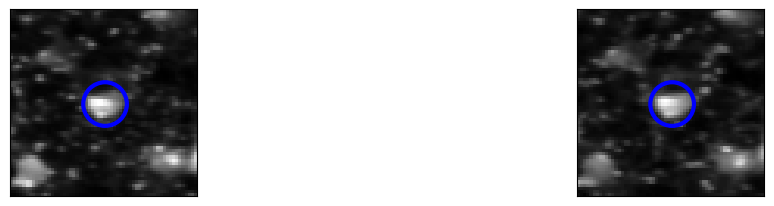

In [66]:
fig = plt.figure(figsize = [25, 5])
gs = gridspec.GridSpec(6, 7, figure=fig)
cell = 0
day0_com = (sess.s2p_stats['channel_1'][0][cell]['xpix'].mean(), sess.s2p_stats['channel_1'][0][cell]['ypix'].mean())
day5_com = (sess.s2p_stats['channel_1'][len(sess.s2p_stats)-1][cell]['xpix'].mean(), sess.s2p_stats['channel_1'][len(sess.s2p_stats)-1][cell]['ypix'].mean())
        
sz = 30
day0img = np.zeros([int(sz*2), int(sz*2),3])



x_edges = (int(day0_com[1]-sz), int(day0_com[1]+sz))
y_edges = ( int(day0_com[0]-sz), int(day0_com[0]+sz))
g_img = sess.s2p_ops['channel_1'][0]['meanImg'][x_edges[0]:x_edges[1], y_edges[0]:y_edges[1]]
# r_img = sess.s2p_ops['channel_1'][0]['meanImg_chan2'][x_edges[0]:x_edges[1], y_edges[0]:y_edges[1]]

g_img = np.minimum(g_img/np.percentile(g_img,100),1)
        # r_img = np.minimum(r_img/np.percentile(r_img, 100),1)
        
day0_ax_g = fig.add_subplot(gs[0:3,3])
day0_ax_g.imshow(g_img,cmap='Greys_r')
day0_ax_g.set_xticks([])
day0_ax_g.set_yticks([])
        
        
        
circle = plt.Circle((sz, sz), 7, fill=False, color='blue',linewidth=3)
day0_ax_g.add_patch(circle)
        
day5img = np.zeros([int(sz*2), int(sz*2), 3])

x_edges = (int(day5_com[1]-sz), int(day5_com[1]+sz))
y_edges = ( int(day5_com[0]-sz), int(day5_com[0]+sz))
g_img = sess.s2p_ops['channel_1'][-1]['meanImg'][x_edges[0]:x_edges[1], y_edges[0]:y_edges[1]]

g_img = np.minimum(g_img/np.percentile(g_img,100),1)
        
        
day5_ax_g = fig.add_subplot(gs[0:3,5])
day5_ax_g.imshow(g_img,cmap='Greys_r')
day5_ax_g.set_xticks([])
day5_ax_g.set_yticks([])
        
        
circle = plt.Circle((sz, sz), 7, fill=False, color='blue',linewidth=3)
day5_ax_g.add_patch(circle)
    


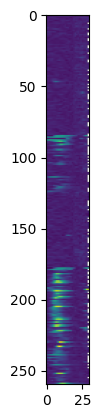

In [67]:
fig, ax = plt.subplots()
ax.imshow(sess.trial_matrices['channel_1_F_dff'][:,:,cell])